In [42]:
import tensorflow
from tensorflow import keras

In [43]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [44]:
X, y = make_moons(
    n_samples = 1000,
    noise = 0.25,
    random_state = 42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state= 42
)

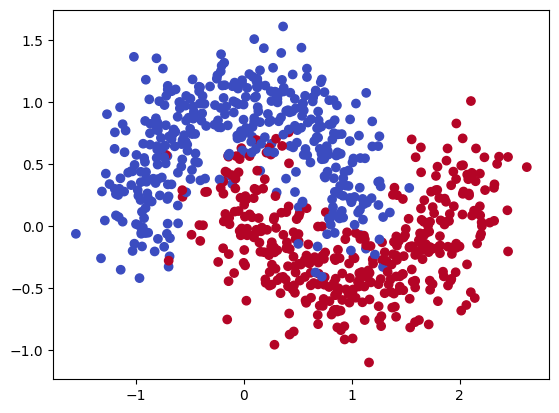

In [45]:
plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c = y_train,
    cmap = 'coolwarm'
)
plt.show()

In [46]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

In [47]:
model = Sequential([
    Dense(128, activation = 'relu', input_shape = (2,)),
    Dense(128, activation = 'relu'),
    Dense(1, activation = 'sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
adam = Adam(learning_rate = 0.01)
model.compile(
    optimizer = adam,
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [49]:
history = model.fit(
    X_train,
    y_train,
    epochs = 500,
    validation_data = (X_test, y_test),
    verbose = 1
)

Epoch 1/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8325 - loss: 0.3606 - val_accuracy: 0.8600 - val_loss: 0.2748
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8838 - loss: 0.2606 - val_accuracy: 0.9000 - val_loss: 0.2121
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9175 - loss: 0.2179 - val_accuracy: 0.9400 - val_loss: 0.1445
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9350 - loss: 0.1827 - val_accuracy: 0.9600 - val_loss: 0.1251
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9300 - loss: 0.1694 - val_accuracy: 0.9500 - val_loss: 0.1185
Epoch 6/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9312 - loss: 0.1508 - val_accuracy: 0.9300 - val_loss: 0.1534
Epoch 7/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9312 - loss: 0.1612 - val_accuracy: 0.9550 - val_loss: 0.1323
Epoch 8/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9312 - loss: 0.1521 - val_accuracy: 0.9600 - 

In [50]:
from mlxtend.plotting import plot_decision_regions

In [51]:
y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step


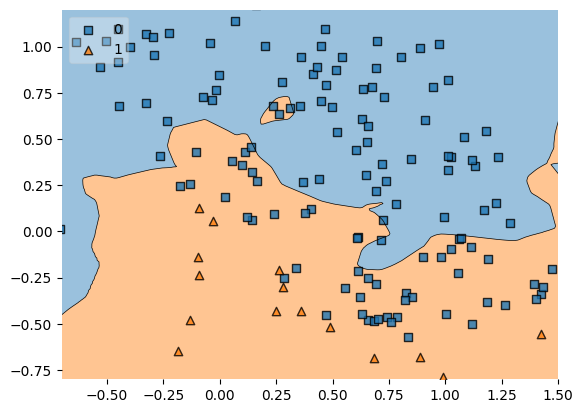

In [52]:
plot_decision_regions(
    X = X_test,
    y = y_pred.astype(int)[:, 0],
    clf = model,
    legend = 2
)
plt.ylim(-0.8, 1.2)
plt.xlim(-0.7, 1.5)
plt.show()

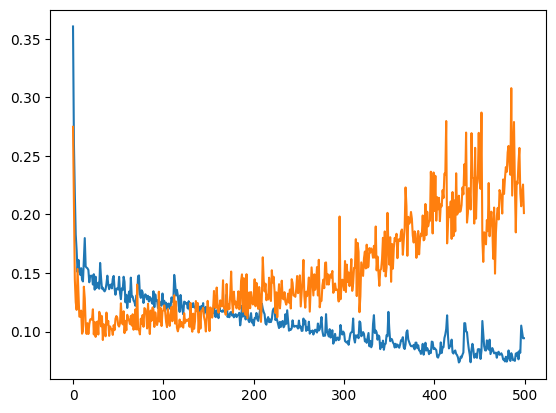

In [53]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [63]:
from keras.layers import Dropout

model = Sequential([
    Dense(128, activation='relu', input_shape=(2,)),
    Dropout(0.5),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

In [64]:
adam = Adam(learning_rate = 0.01)
model.compile(
    optimizer = adam,
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [65]:
history = model.fit(
    X_train,
    y_train,
    epochs = 500,
    validation_data = (X_test, y_test),
    verbose = 1
)

Epoch 1/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8350 - loss: 0.4155 - val_accuracy: 0.8200 - val_loss: 0.3648
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8600 - loss: 0.3327 - val_accuracy: 0.8650 - val_loss: 0.2804
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8612 - loss: 0.2958 - val_accuracy: 0.8550 - val_loss: 0.2609
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8825 - loss: 0.2800 - val_accuracy: 0.8850 - val_loss: 0.2459
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8925 - loss: 0.2559 - val_accuracy: 0.9000 - val_loss: 0.1998
Epoch 6/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9000 - loss: 0.2523 - val_accuracy: 0.9200 - val_loss: 0.1928
Epoch 7/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9100 - loss: 0.2364 - val_accuracy: 0.9250 - val_loss: 0.1732
Epoch 8/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9250 - loss: 0.2133 - val_accuracy: 0.9500 - 

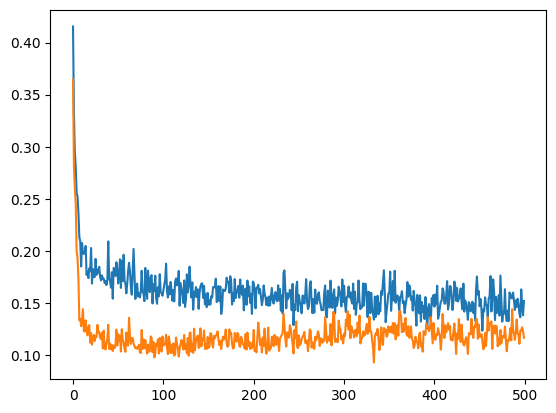

In [66]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [67]:
y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


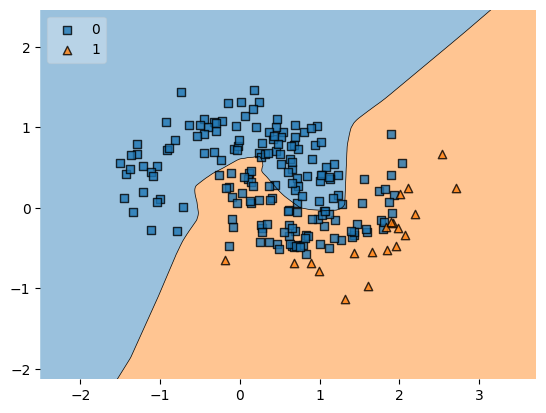

In [68]:
plot_decision_regions(
    X = X_test,
    y = y_pred.astype(int)[:, 0],
    clf = model,
    legend = 2
)
plt.show()